# Maximal scattering bound in the scattered-voltage basis without Cholesky whitening

Bound on the scattered power $\tfrac12 I^H R_0 I$ of a plane-wave excited structure carved out of a design region, with the
scattered voltage $V_\mathrm{sca} = -Z_0 I$ in the original RWG basis as the degree of freedom (equivalent of
`maxScatIvecNoChol.ipynb`, which uses the current). The material operator stays non-diagonal,
$Z_\mathrm{mat} = Z_s L$, and the system matrix is $Z_\mathrm{tot} = Z_0 + Z_s L$.

A structure is a subset of enabled basis functions, i.e. $I = D (D Z_\mathrm{tot} D + (1 - D))^{-1} D V$ with $D = \operatorname{diag}(d_i)$,
$d_i \in \{0, 1\}$. Every such structure satisfies the pointwise relation
$$w_i = I_i^* \left(V - Z_\mathrm{tot} I\right)_i = 0,$$
since either $I_i = 0$ (removed basis function) or the $i$-th row of the system equation holds (kept basis function; the removed
columns of $Z_\mathrm{tot}$ multiply $I_j = 0$). No whitening of $L$ is needed for this argument.

The current is eliminated by the field equation, valid everywhere, $I = -W V_\mathrm{sca}$ with $W = Z_0^{-1}$, an invertible
linear change of variables, so all bounds must coincide with the current basis.

Steps: global bound (real and reactive power), 40 GCD iterations, all-pointwise (full local) bound, and the inference of $d_i$
from the dual solutions by pointwise fits and by the Lagrangian-weighted solution fit.

In [1]:
import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp

from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters
from dolphindes.cvxopt.gcd import GCDHyperparameters

In [2]:
matrixSet = "dipole"   # "dipole" | "patch21ka1": operators loaded from *_{matrixSet}.txt (both ka = 1)

# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
omega = 2 * np.pi * frequency # angular frequency

copper_conductivity = 5.96e7 # S/m
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta) # surface impedance
print(f"Surface impedance: {Zs} Ω")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω


In [3]:
def Msym(M):
    return(0.5*(M.conj().T + M))

# Load matrices from text files (original RWG basis, no Cholesky transformation)
Lmat = np.loadtxt(f"Lmat_{matrixSet}.txt", delimiter=',') # lossy matrix
R0 = Msym(np.loadtxt(f"R0_{matrixSet}.txt", delimiter=',')) # radiated power matrix
X0 = Msym(np.loadtxt(f"X0_{matrixSet}.txt", delimiter=',')) # reactive power matrix
Vinc = E0*np.loadtxt(f"V_{matrixSet}.txt", delimiter=',').astype(complex) # voltage excitation vector

Ndes = Lmat.shape[0] # number of design variables
print(f"Matrix set: {matrixSet}, number of design variables: {Ndes}")

Zmat = Zs * Lmat # material impedance matrix (non-diagonal)
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix
Ldiag = np.diag(Lmat).copy() # diagonal of the lossy matrix

def evalObj(Ivec):
    # scattered (radiated) power
    return(0.5*np.real(Ivec.conj() @ R0 @ Ivec))

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc)
Pfull = evalObj(Ifull)
print(f"Objective for full plate: {Pfull:.6e} W")
print(f"||L - diag(L)||_F / ||L||_F = {np.linalg.norm(Lmat - np.diag(Ldiag))/np.linalg.norm(Lmat):.3f} (non-diagonal material operator)")

Matrix set: dipole, number of design variables: 195
Objective for full plate: 1.010821e+01 W
||L - diag(L)||_F / ||L||_F = 0.140 (non-diagonal material operator)


## QCQP in the scattered-voltage basis

Dolphindes maximizes $-x^H A_0 x + 2\operatorname{Re}(x^H s_0) + c_0$ subject to
$\operatorname{Re}(-x^H A_1 P A_2 x + 2 x^H A_2^H P^H s_1) = 0$. With $x = V_\mathrm{sca}$ and $I = -W x$, the objective is
$$A_0 = -\tfrac12 W^H R_0 W,\qquad s_0 = 0,\qquad c_0 = 0 .$$
The pointwise relation reads $w_i = I_i^* (V + V_\mathrm{sca} - Z_\mathrm{mat} I)_i$, so for $P = \operatorname{diag}(p)$
$$\operatorname{Re}\sum_i p_i^* w_i = \operatorname{Re}\left[-x^H W^H P^H (1 + Z_\mathrm{mat} W) x - x^H W^H P^H V\right].$$
Using $\operatorname{Re}(x^H M x) = \operatorname{Re}(x^H M^H x)$ this is the shared projector form with
$$A_1 = 1 + W^H Z_\mathrm{mat}^H,\qquad A_2 = W,\qquad s_1 = -\tfrac12 V ,$$
which for $Z_\mathrm{mat} = Z_s \mathbf 1$ reduces to `VscatBound.ipynb`. The global real and reactive power constraints are $p = \mathbf 1$ and
$p = j\mathbf 1$. For $p = \mathbf 1$, $\operatorname{Sym}(A_1 A_2) = W^H (R_0 + \operatorname{Re}(Z_s) L) W$, so the real power multiplier $\lambda = 1$ gives
$A = W^H (\tfrac12 R_0 + \operatorname{Re}(Z_s) L) W \succ 0$, a dual feasible starting point.

In [4]:
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}")
W = np.linalg.inv(Z0) # Z0^{-1}
WH = W.conj().T

Obj = -0.5 * Msym(WH @ R0 @ W)
obj = np.zeros(Ndes, dtype=complex)
obj0 = 0.0
A1 = np.eye(Ndes) + WH @ Zmat.conj().T
A2 = W
s1 = -0.5 * Vinc

def VtoI(Vsca):
    return(-W @ Vsca)

def localViolation(I):
    # pointwise w_i = I_i^* (V - Ztot I)_i, zero for any structure made of enabled basis functions
    return(np.conj(I)*(Vinc - Ztot @ I))

def projRes(x, p):
    # Re(-x^H A1 P A2 x + 2 x^H A2^H P^H s1) for P = diag(p)
    return(np.real(-x.conj() @ A1 @ (p*(A2 @ x)) + 2*x.conj() @ (WH @ (np.conj(p)*s1))))

# check: shared projector form equals the pointwise form, and vanishes for full plate and a random binary structure
rng = np.random.default_rng(0)
pRand = rng.standard_normal(Ndes) + 1j*rng.standard_normal(Ndes)
xRand = rng.standard_normal(Ndes) + 1j*rng.standard_normal(Ndes)
print(f"random p, random x: shared form {projRes(xRand, pRand):.6e}, "
      f"pointwise {np.real(np.sum(np.conj(pRand)*localViolation(VtoI(xRand)))):.6e}")

dTest = rng.random(Ndes) > 0.5
Itest = np.zeros(Ndes, dtype=complex)
Itest[dTest] = np.linalg.solve(Ztot[np.ix_(dTest, dTest)], Vinc[dTest])
for name, I in [("full plate", Ifull), ("random binary", Itest)]:
    x = -Z0 @ I
    print(f"{name}: max |w_i| / |I^H V| = {np.max(np.abs(localViolation(VtoI(x))))/np.abs(I.conj() @ Vinc):.2e}, "
          f"P(x) {-np.real(x.conj() @ Obj @ x):.6e} W (I basis {evalObj(I):.6e} W)")

cond(Z0) = 1.167e+04
random p, random x: shared form -5.973849e+05, pointwise -5.973849e+05
full plate: max |w_i| / |I^H V| = 1.58e-13, P(x) 1.010821e+01 W (I basis 1.010821e+01 W)
random binary: max |w_i| / |I^H V| = 1.05e-14, P(x) 6.477488e-07 W (I basis 6.477488e-07 W)


## Inference of $d_i$

Relaxing $d_i$ to $[0, 1]$ in $I = D (D Z_\mathrm{tot} D + (1 - D))^{-1} D V$ is equivalent to a series impedance at each basis function,
$$\left(Z_\mathrm{tot} + \operatorname{diag}(r_i)\right) I = V, \qquad r_i = Z_s L_{ii}\left(\frac{1}{d_i} - 1\right),$$
scaled so that $d_i = 1$ is the material and $d_i \to 0$ removes the basis function. Two projections of a dual current $I^\star$ onto
$d_i \in [0, 1]$ are compared.

**Impedance form.** The inferred series impedance is projected onto the passive ray $Z_s L_{ii}\,[0, \infty)$,
$$r_i = \frac{(V - Z_\mathrm{tot} I^\star)_i}{I^\star_i}, \qquad
t_i = \max\left(0, \frac{\operatorname{Re}(Z_s^* r_i)}{|Z_s|^2 L_{ii}}\right), \qquad d_i = \frac{1}{1 + t_i},$$
with $d_i = 0$ where $I^\star_i = 0$. An active $r_i$ ($\operatorname{Re}(Z_s^* r_i) < 0$) is mapped to $d_i = 1$.

**Admittance form.** Moving the self term $Z_s L_{ii}$ to the right gives the bounded form
$$Z_s L_{ii}\, I_i = d_i\, u_i, \qquad u = V - \left(Z_\mathrm{tot} - Z_s \operatorname{diag}(L_{ii})\right) I,$$
where $u_i$ is the voltage driving the $i$-th basis function without its own material self term. The impedance form
$d_i = 1/(1 + r_i/(Z_s L_{ii}))$ is the same relation, but $r_i = (V - Z_\mathrm{tot} I)_i / I_i$ diverges with an arbitrary phase for $I_i \to 0$,
so its projection onto the passive ray can return $d_i = 1$ on a removed basis function. The admittance form is regular at both ends.
The density is fitted pointwise in the current,
$$d_i = \arg\min_{d \in [0,1]} \left| I^\star_i - d\, b_i \right|^2 = \operatorname{clip}\left(\frac{\operatorname{Re}(b_i^* I^\star_i)}{|b_i|^2}, 0, 1\right), \qquad b_i = \frac{u_i}{Z_s L_{ii}} .$$
Both forms recover any binary structure exactly; they differ on the non-physical dual currents.
The inferred design is evaluated by solving the relaxed system; basis functions with $d_i < d_\mathrm{min}$ are removed.

In [5]:
dMin = 1e-6 # basis functions with d_i < dMin are removed in the realized structure

def inferDimp(I):
    # impedance form: series impedance projected onto the passive ray, d = 1/(1 + t)
    nz = I != 0
    r = np.zeros(Ndes, dtype=complex)
    r[nz] = (Vinc - Ztot @ I)[nz]/I[nz] # inferred series impedance per basis function
    t = np.maximum(0, np.real(np.conj(Zs)*r)/(np.abs(Zs)**2*Ldiag))
    return np.where(nz, 1/(1 + t), 0.0)

def inferDadm(I):
    # admittance form: pointwise current fit of Zs Lii I_i = d_i u_i
    u = Vinc - Ztot @ I + Zs*Ldiag*I # driving voltage without the material self term
    b = u/(Zs*Ldiag) # current of a full material basis function driven by u
    return np.clip(np.real(np.conj(b)*I)/np.abs(b)**2, 0, 1)

inferForms = {"impedance form": inferDimp, "admittance form": inferDadm}

def realizedCurrent(d):
    # (Ztot + diag(Zs Lii (1/d - 1))) I = V on the kept basis functions, I = 0 elsewhere
    keep = d >= dMin
    I = np.zeros(Ndes, dtype=complex)
    Zd = Ztot + np.diag(Zs*Ldiag*(1/np.maximum(d, dMin) - 1))
    I[keep] = np.linalg.solve(Zd[np.ix_(keep, keep)], Vinc[keep])
    return I

def realizedObj(d):
    return evalObj(realizedCurrent(d))

ths = np.linspace(0.05, 0.95, 19) # thresholds for binary rounding of d

# check: the full plate and the random binary structure are recovered exactly
for name, I, dTrue in [("full plate", Ifull, np.ones(Ndes)), ("random binary", Itest, dTest.astype(float))]:
    for form, infer in inferForms.items():
        d = infer(I)
        print(f"{name}, {form}: max |d - d_true| = {np.max(np.abs(d - dTrue)):.2e}, "
              f"realized objective {realizedObj(d):.6e} W (true {evalObj(I):.6e} W)")

full plate, impedance form: max |d - d_true| = 6.21e-10, realized objective 1.010821e+01 W (true 1.010821e+01 W)
full plate, admittance form: max |d - d_true| = 6.21e-10, realized objective 1.010821e+01 W (true 1.010821e+01 W)
random binary, impedance form: max |d - d_true| = 4.70e-10, realized objective 6.477488e-07 W (true 6.477488e-07 W)
random binary, admittance form: max |d - d_true| = 4.70e-10, realized objective 6.477488e-07 W (true 6.477488e-07 W)


## Lagrangian-weighted solution fitting

The pointwise fits compare the dual current with a model that is linear in $d$ and evaluated with the dual driving voltage.
Here the dual solution $x^\star$ is compared with the exact solution of the structure with density $d$ (`main.tex`,
Lagrangian-weighted solution fitting), in the norm of the Lagrangian Hessian $L^\star = \operatorname{Sym} A(\lambda^\star)$ at the optimal
multipliers in the variable $x$ of the bound,
$$\min_{d \in [0,1]^N} J(d), \qquad J(d) = \left(x(d) - x^\star\right)^H L^\star \left(x(d) - x^\star\right), \qquad x(d) = T\, I(d),$$
with $T = \mathbf 1$ in the current basis and $T = -Z_0$ in the scattered-voltage basis. With the non-diagonal material operator, the
realized current follows from the admittance form $Z_s L_{ii} I_i = d_i u_i$,
$$I(d) = M^{-1}(d)\, \operatorname{diag}(d)\, V, \qquad M(d) = Z_s \operatorname{diag}(L_{ii}) + \operatorname{diag}(d)\, Z', \qquad Z' = Z_\mathrm{tot} - Z_s \operatorname{diag}(L_{ii}),$$
which is regular at $d_i = 0$ (removed basis function, $I_i = 0$) and gives $M = Z_\mathrm{tot}$ for $d = \mathbf 1$; for $L = \mathbf 1$ it reduces to
$M = Z_s + \operatorname{diag}(d) Z_0$ of the whitened basis. With $L^\star = C^H C$ (eigendecomposition, round-off negative eigenvalues set to zero),
the fit is the bounded nonlinear least-squares problem $\min_d \|C(x(d) - x^\star)\|^2$ with the Jacobian
$$\frac{\partial x(d)}{\partial d_j} = T M^{-1}(d)\, e_j \left[V - Z' I(d)\right]_j ,$$
solved by a bounded trust-region method started from both pointwise fits, keeping the result with the smaller $J$.
For a binary $d$ the realized current satisfies all constraints, so $f_0 = D - J$; for intermediate $d$ the constraints are violated and
$J \neq D - f_0$. $J$ is reported for all inferred densities together with $D - f_0$.

In [6]:
from scipy.optimize import least_squares

TX = -Z0 # x = TX I, the variable of the bound

def xToI(x):
    return np.linalg.solve(TX, x)

Zoff = Ztot - Zs*np.diag(Ldiag) # system matrix without the material self terms

def solutionModel(d):
    # admittance form: (Zs diag(Lii) + diag(d) Z') I = diag(d) V
    M = Zs*np.diag(Ldiag) + d[:, None]*Zoff
    return M, np.linalg.solve(M, d*Vinc)

def lagFactor(Q):
    # C with C^H C = Sym A(lambda*), from the eigendecomposition (L* is nearly singular)
    lam, U = np.linalg.eigh(Msym(Q._get_total_A(Q.current_lags)))
    return np.sqrt(np.maximum(lam, 0))[:, None] * U.conj().T

def stackRI(M):
    return np.vstack([M.real, M.imag]) if M.ndim == 2 else np.concatenate([M.real, M.imag])

def lagDist(C, xs, d):
    # J(d) = ||C (x(d) - x*)||^2
    return np.linalg.norm(C @ (TX @ solutionModel(d)[1] - xs))**2

def fitSolutionLag(C, xs, d0):
    # argmin_{d in [0,1]^N} ||C (x(d) - x*)||^2
    CT = C @ TX
    Cx = C @ xs
    def fun(d):
        return stackRI(CT @ solutionModel(d)[1] - Cx)
    def jac(d):
        M, I = solutionModel(d)
        return stackRI((CT @ np.linalg.inv(M)) * (Vinc - Zoff @ I)[None, :]) # column j: T M^{-1} e_j [V - Z' I]_j
    sol = least_squares(fun, np.clip(d0, 1e-3, 1 - 1e-3), jac=jac, bounds=(0, 1), method='trf',
                        xtol=1e-12, ftol=1e-12, max_nfev=500)
    return sol.x

formStyle = {"impedance form": '-', "admittance form": '--', "Lagrangian solution fit": ':'}

def reportInference(name, Q):
    xs = Q.current_xstar
    I = xToI(xs)
    C = lagFactor(Q)
    D = Q.current_dual
    dPoint = {form: infer(I) for form, infer in inferForms.items()}
    t1 = time.time()
    starts = {form: fitSolutionLag(C, xs, d0) for form, d0 in dPoint.items()}
    best = min(starts, key=lambda form: lagDist(C, xs, starts[form]))
    print(f"{name}: Lagrangian solution fit {time.time()-t1:.2f}s, smaller J from the {best} start")
    out = {}
    for form, d in [*dPoint.items(), ("Lagrangian solution fit", starts[best])]:
        Pbin = np.array([realizedObj((d > t).astype(float)) for t in ths])
        P = realizedObj(d)
        print(f"{name}, {form}: d in [{d.min():.3e}, {d.max():.3e}], mean {d.mean():.3f}, #(d > 0.5) {np.count_nonzero(d > 0.5)}/{Ndes}, "
              f"realized objective {P:.6e} W, J {lagDist(C, xs, d):.3e} W (D - P {D - P:.3e} W), "
              f"best binary {Pbin.max():.6e} W (threshold {ths[np.argmax(Pbin)]:.2f})")
        out[form] = (d, Pbin)
    return out

def barD(ax, inferred, title):
    w = 0.3
    for k, (form, (d, _)) in enumerate(inferred.items()):
        ax.bar(np.arange(Ndes) + (k - 1)*w, d, width=w, label=form)
    ax.set_ylabel(r'$d_i$'); ax.set_title(title); ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(True)

# check: the solution model reproduces the full plate and the random binary structure, J = 0 for x* = x(d_true)
for name, I, dTrue in [("full plate", Ifull, np.ones(Ndes)), ("random binary", Itest, dTest.astype(float))]:
    print(f"{name}: ||I(d_true) - I|| / ||I|| = {np.linalg.norm(solutionModel(dTrue)[1] - I)/np.linalg.norm(I):.2e}")

full plate: ||I(d_true) - I|| / ||I|| = 0.00e+00
random binary: ||I(d_true) - I|| / ||I|| = 1.04e-10


## Global bound

In [7]:
opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

PlistGlob = [sp.diags(q*np.ones(Ndes, dtype=complex)) for q in [1, 1j]] # global real and reactive power
QCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, PlistGlob, A2=A2, verbose=0)

lags_init = np.array([1.0, 0.0]) # lambda = 1 on the real power constraint
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

t1 = time.time()
QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
dualGlob = QCQP.current_dual
Iglob = VtoI(QCQP.current_xstar)
print(f"global bound: {dualGlob:.6e} W, P(I*) {evalObj(Iglob):.6e} W, full plate {Pfull:.6e} W, time {time.time()-t1:.2f}s")
print(f"Lagrange multipliers: {QCQP.current_lags}")
print(f"constraint residuals at x*: {[f'{projRes(QCQP.current_xstar, q*np.ones(Ndes)):.2e}' for q in [1, 1j]]}")

initial lags dual feasible: True


global bound: 1.012093e+01 W, P(I*) 1.012093e+01 W, full plate 1.010821e+01 W, time 0.08s
Lagrange multipliers: [ 0.98806808 -0.03777125]
constraint residuals at x*: ['2.99e-08', '4.09e-07']


## 40 GCD iterations

Starting from the global constraints, `run_gcd` adds two diagonal projectors per iteration (strongest local violation $w_i$ and
minimal eigenvalue of $A(\lambda)$); `max_proj_cstrt_num` is large enough that no projectors are merged.

In [8]:
Ngcd = 40 # number of GCD iterations

gQCQP = copy.deepcopy(QCQP)
gQCQP.verbose = 0
gcd_params = GCDHyperparameters(max_proj_cstrt_num=2 + 2*Ngcd,
    max_gcd_iter_num=Ngcd,
    gcd_iter_period=Ngcd + 1, # no early termination
    opt_params=opt_params)

t1 = time.time()
gQCQP.run_gcd(gcd_params)
Igcd = VtoI(gQCQP.current_xstar)
print(f"bound: global {dualGlob:.6e} -> GCD {gQCQP.current_dual:.6e} W (full plate {Pfull:.6e} W), "
      f"{gQCQP.n_proj_constr} projectors, {time.time()-t1:.2f}s")
print(f"||w||: global {np.linalg.norm(localViolation(Iglob)):.3e}, GCD {np.linalg.norm(localViolation(Igcd)):.3e}")

At GCD iteration #1, best dual bound found is             10.12093276012632.
min eigenvalue: 1.358895e+01


At GCD iteration #2, best dual bound found is             10.11319131287117.


min eigenvalue: 1.064566e+01
At GCD iteration #3, best dual bound found is             10.113154125381579.
min eigenvalue: 1.063146e+01


At GCD iteration #4, best dual bound found is             10.112287128851126.
min eigenvalue: 1.030413e+01


At GCD iteration #5, best dual bound found is             10.111320568448496.
min eigenvalue: 9.903647e+00
At GCD iteration #6, best dual bound found is             10.110993410949813.
min eigenvalue: 9.762545e+00


...

At GCD iteration #36, best dual bound found is             10.108453147671801.
min eigenvalue: 8.343328e+00
At GCD iteration #37, best dual bound found is             10.10841778180119.
min eigenvalue: 8.316876e+00


At GCD iteration #38, best dual bound found is             10.108393125589886.
min eigenvalue: 8.299401e+00


At GCD iteration #39, best dual bound found is             10.108377013468832.
min eigenvalue: 8.289918e+00


At GCD iteration #40, best dual bound found is             10.108364936311919.
min eigenvalue: 8.282495e+00


At GCD iteration #41, best dual bound found is             10.108356035259426.
bound: global 1.012093e+01 -> GCD 1.010836e+01 W (full plate 1.010821e+01 W), 82 projectors, 5.89s
||w||: global 8.605e-01, GCD 4.259e-01


dual bound: global 1.012093e+01 W, GCD 1.010836e+01 W, full plate 1.010821e+01 W
global constraints: Lagrangian solution fit 0.16s, smaller J from the admittance form start
global constraints, impedance form: d in [3.675e-04, 1.000e+00], mean 0.475, #(d > 0.5) 89/195, realized objective 7.780955e+00 W, J 3.158e-01 W (D - P 2.340e+00 W), best binary 1.890396e-02 W (threshold 0.05)
global constraints, admittance form: d in [0.000e+00, 1.000e+00], mean 0.022, #(d > 0.5) 2/195, realized objective 9.606852e-04 W, J 1.011e+01 W (D - P 1.012e+01 W), best binary 1.825120e-08 W (threshold 0.05)
global constraints, Lagrangian solution fit: d in [1.000e+00, 1.000e+00], mean 1.000, #(d > 0.5) 195/195, realized objective 1.010821e+01 W, J 1.272e-02 W (D - P 1.272e-02 W), best binary 1.010821e+01 W (threshold 0.05)


global + GCD, 40 iterations: Lagrangian solution fit 0.19s, smaller J from the impedance form start
global + GCD, 40 iterations, impedance form: d in [1.165e-04, 1.000e+00], mean 0.538, #(d > 0.5) 98/195, realized objective 9.009978e+00 W, J 6.290e-02 W (D - P 1.098e+00 W), best binary 1.111642e-04 W (threshold 0.05)
global + GCD, 40 iterations, admittance form: d in [0.000e+00, 9.095e-01], mean 0.031, #(d > 0.5) 1/195, realized objective 4.290068e-07 W, J 1.011e+01 W (D - P 1.011e+01 W), best binary 1.801617e-08 W (threshold 0.05)
global + GCD, 40 iterations, Lagrangian solution fit: d in [2.464e-01, 1.000e+00], mean 0.961, #(d > 0.5) 193/195, realized objective 1.010690e+01 W, J 1.429e-04 W (D - P 1.454e-03 W), best binary 1.010821e+01 W (threshold 0.05)


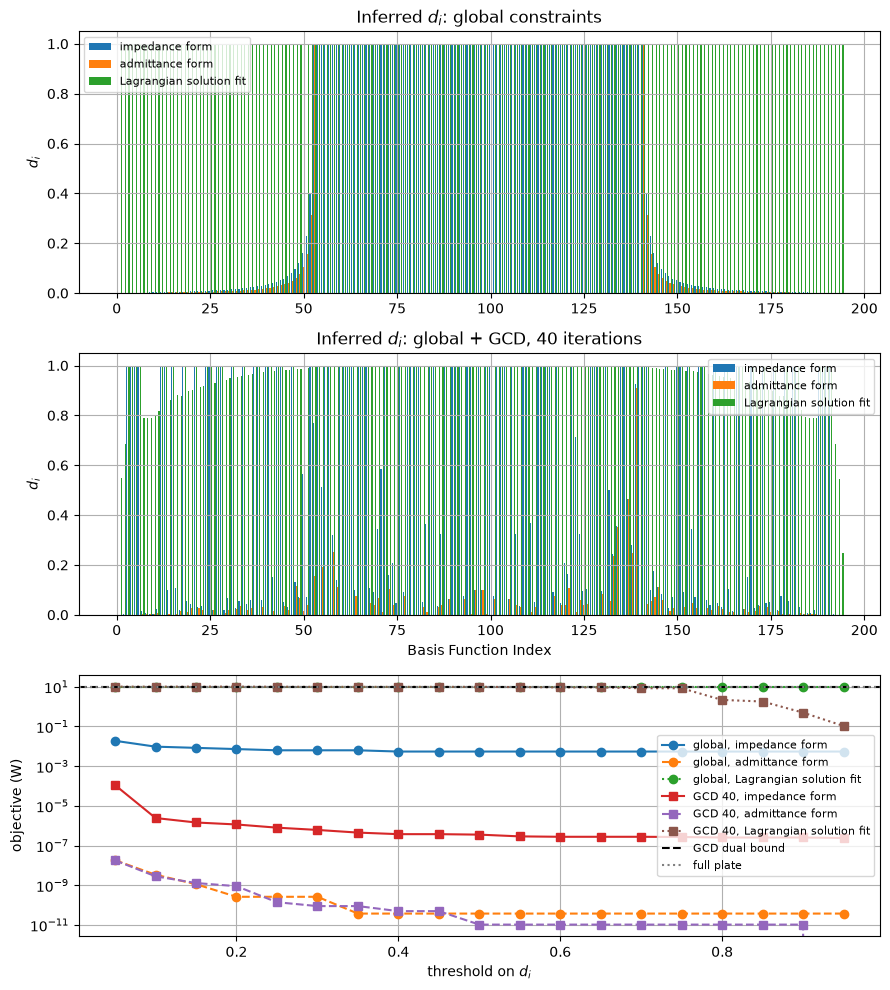

In [9]:
print(f"dual bound: global {dualGlob:.6e} W, GCD {gQCQP.current_dual:.6e} W, full plate {Pfull:.6e} W")
infGlob = reportInference("global constraints", QCQP)
infGcd = reportInference(f"global + GCD, {Ngcd} iterations", gQCQP)

fig, axes = plt.subplots(3, 1, figsize=(9, 10))
barD(axes[0], infGlob, 'Inferred $d_i$: global constraints')
barD(axes[1], infGcd, f'Inferred $d_i$: global + GCD, {Ngcd} iterations')
axes[1].set_xlabel('Basis Function Index')
for (name, inf), mk in zip([("global", infGlob), (f"GCD {Ngcd}", infGcd)], ['o', 's']):
    for form, (_, Pbin) in inf.items():
        axes[2].plot(ths, Pbin, mk + formStyle[form], label=f'{name}, {form}')
axes[2].axhline(gQCQP.current_dual, ls='--', c='k', label='GCD dual bound')
axes[2].axhline(Pfull, ls=':', c='gray', label='full plate')
axes[2].set_yscale('log')
axes[2].set_xlabel(r'threshold on $d_i$'); axes[2].set_ylabel('objective (W)'); axes[2].legend(fontsize=8); axes[2].grid(True)
plt.tight_layout(); plt.show()

## Full local solve

All pointwise constraints, $p = e_i$ (real power) and $p = j e_i$ (reactive power) for every basis function, $2N$ projectors.
The multipliers $\lambda_i = 1$ on the real power constraints sum to the global real power constraint with $\lambda = 1$, a dual
feasible starting point.

In [10]:
Pdiags = np.column_stack([np.eye(Ndes, dtype=complex), 1j*np.eye(Ndes, dtype=complex)])
PlistAll = [sp.diags(Pdiags[:, i]) for i in range(Pdiags.shape[1])]
print(f"number of projector constraints: {len(PlistAll)}")

fQCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, PlistAll, A2=A2, verbose=0)
lags_init = np.zeros(2*Ndes)
lags_init[:Ndes] = 1.0 # lambda_i = 1 on all real power constraints
print(f"initial lags dual feasible: {fQCQP.is_dual_feasible(lags_init)}")

full_opt_params = OptimizationHyperparameters(opttol=1e-10,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=30,
    penalty_ratio=1e-3,
    penalty_reduction=0.01,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
fQCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=full_opt_params)
Iloc = VtoI(fQCQP.current_xstar)
print(f"full local bound: {fQCQP.current_dual:.6e} W, P(I*) {evalObj(Iloc):.6e} W, GCD {gQCQP.current_dual:.6e} W, "
      f"global {dualGlob:.6e} W, full plate {Pfull:.6e} W, time {time.time()-t1:.2f}s")
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(fQCQP._get_total_A(fQCQP.current_lags)))):.3e}")
print(f"max |w_i| / |I*^H V| = {np.max(np.abs(localViolation(Iloc)))/np.abs(Iloc.conj() @ Vinc):.2e}, "
      f"||I* - Ifull|| / ||Ifull|| = {np.linalg.norm(Iloc - Ifull)/np.linalg.norm(Ifull):.2e}")

number of projector constraints: 390


initial lags dual feasible: True


full local bound: 1.010821e+01 W, P(I*) 1.010821e+01 W, GCD 1.010836e+01 W, global 1.012093e+01 W, full plate 1.010821e+01 W, time 14.28s
minimum eigenvalue of A: 8.192e+00
max |w_i| / |I*^H V| = 2.39e-07, ||I* - Ifull|| / ||Ifull|| = 5.54e-09


full local: Lagrangian solution fit 0.01s, smaller J from the impedance form start
full local, impedance form: d in [9.988e-01, 1.000e+00], mean 1.000, #(d > 0.5) 195/195, realized objective 1.010820e+01 W, J 1.322e-11 W (D - P 1.590e-05 W), best binary 1.010821e+01 W (threshold 0.05)
full local, admittance form: d in [9.988e-01, 1.000e+00], mean 1.000, #(d > 0.5) 195/195, realized objective 1.010820e+01 W, J 1.324e-11 W (D - P 1.591e-05 W), best binary 1.010821e+01 W (threshold 0.05)
full local, Lagrangian solution fit: d in [9.988e-01, 9.990e-01], mean 0.999, #(d > 0.5) 195/195, realized objective 1.010804e+01 W, J 1.587e-09 W (D - P 1.747e-04 W), best binary 1.010821e+01 W (threshold 0.05)


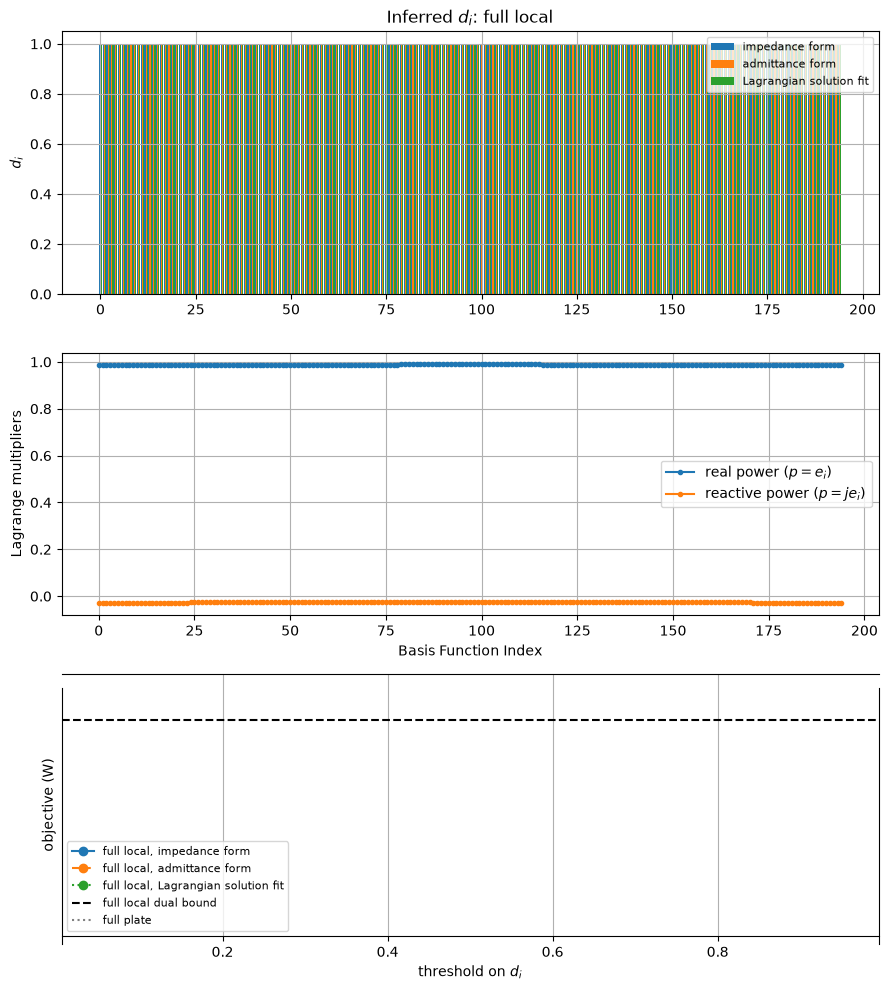

In [11]:
infLoc = reportInference("full local", fQCQP)
lags = fQCQP.current_lags

fig, axes = plt.subplots(3, 1, figsize=(9, 10))
barD(axes[0], infLoc, 'Inferred $d_i$: full local')
axes[1].plot(np.arange(Ndes), lags[:Ndes], '.-', label=r'real power ($p = e_i$)')
axes[1].plot(np.arange(Ndes), lags[Ndes:], '.-', label=r'reactive power ($p = j e_i$)')
axes[1].set_ylabel('Lagrange multipliers'); axes[1].set_xlabel('Basis Function Index'); axes[1].legend(); axes[1].grid(True)
for form, (_, Pbin) in infLoc.items():
    axes[2].plot(ths, Pbin, 'o' + formStyle[form], label=f'full local, {form}')
axes[2].axhline(fQCQP.current_dual, ls='--', c='k', label='full local dual bound')
axes[2].axhline(Pfull, ls=':', c='gray', label='full plate')
axes[2].set_yscale('log')
axes[2].set_xlabel(r'threshold on $d_i$'); axes[2].set_ylabel('objective (W)'); axes[2].legend(fontsize=8); axes[2].grid(True)
plt.tight_layout(); plt.show()